# Pipeline reproducible de reservas

Este notebook documenta la línea base pandas equivalente a `pipeline.py`. Lee las tablas de `reservas_db` en CockroachDB E3 y aplica el mismo filtro, join, calendario, agregación por período y clasificación por tamaño.

Requisitos: `pandas`, `sqlalchemy`, `psycopg` y un motor Parquet como `pyarrow`. La variable `RESERVAS_PANDAS_URL` permite sustituir la conexión predeterminada.

## Nota de alcance (corrección #17)

Este notebook documenta únicamente la **reproducibilidad de la línea base
pandas** (`baseline.py`), equivalente funcional del pipeline PySpark. **No**
es el artefacto canónico del análisis de escalabilidad/speedup de la
corrección #17: ese análisis (lectura de `N=1,2,4,6,8`, cálculo de speedup,
ajuste de Amdahl y generación de `speedup.png`) se produce de forma
determinista y probada por el script `experimentos/analyze_speedup.py`
(cubierto por `experimentos/tests/test_speedup.py`), que es la fuente
canónica.

La Sección 5 de este notebook añade una reproducción de ese análisis
**a partir de la evidencia ya versionada** en `experimentos/evidencia-17/`,
sin volver a ejecutar Spark, únicamente para facilitar la inspección
interactiva.

In [ ]:
from baseline import (
    PandasDbConfig,
    agregar_dimensiones_temporales,
    agregar_participantes_por_periodo,
    cargar_fuentes,
    categorizar_numero_participantes,
    crear_motor,
    exportar_parquet,
    filtrar_reservas_activas,
    unir_solicitudes_con_reservas,
)

config = PandasDbConfig.desde_entorno()
motor = crear_motor(config)

## 1. Lectura

Las fuentes corresponden exactamente a las tablas declaradas en `db/schema.sql`.

In [ ]:
fuentes = cargar_fuentes(motor)

## 2. Filtrado y join

Se conservan reservas programadas o en curso y se relacionan 1:1 con su solicitud.

In [ ]:
reservas_activas = filtrar_reservas_activas(fuentes["reservas"])
datos = unir_solicitudes_con_reservas(
    fuentes["solicitudes_reserva"],
    reservas_activas,
)

## 3. Fechas, agregación y clasificación

Se derivan año, trimestre y mes; luego se replica la suma Window por laboratorio y trimestre. Finalmente, el número de participantes se asigna a los mismos intervalos del `Bucketizer` de Spark.

In [ ]:
datos = agregar_dimensiones_temporales(datos)
datos = agregar_participantes_por_periodo(datos)
resultado = categorizar_numero_participantes(datos)
resultado.head()

## 4. Exportación

El resultado reproducible se almacena como `spark/out/reservas_procesadas.parquet`.

In [ ]:
destino = exportar_parquet(resultado)
motor.dispose()
destino

## 5. Reproducción del análisis de escalabilidad Spark (corrección #17)

Esta sección **no ejecuta Spark**: solo lee la evidencia ya versionada en
`experimentos/evidencia-17/20260916/benchmark-definitivo-9d94efe6-7bb7-4227-b78e-c70092e9bcfb/`
(`config.json` y `comparacion.json`) y reproduce, con el script canónico
`experimentos/analyze_speedup.py`, los tiempos, el speedup y el ajuste de
Amdahl publicados en el informe. Usa rutas relativas al repositorio (este
notebook se ejecuta con `spark/` como directorio de trabajo).

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, "../experimentos")
from analyze_speedup import summarize

EVIDENCIA_17 = Path(
    "../experimentos/evidencia-17/20260916/"
    "benchmark-definitivo-9d94efe6-7bb7-4227-b78e-c70092e9bcfb"
)
config = json.loads((EVIDENCIA_17 / "config.json").read_text(encoding="utf-8"))
comparacion = json.loads((EVIDENCIA_17 / "comparacion.json").read_text(encoding="utf-8"))

resumen, ajuste_amdahl = summarize(comparacion, config)
resumen, ajuste_amdahl


([{'treatment': 'pandas-baseline',
   'parallelism': 1,
   'repetitions': 5,
   'rows_processed': 90000,
   'mean_ms': 17326.5594,
   'stddev_ms': 1504.066891305802,
   'speedup_vs_pandas': 1.0,
   'speedup_vs_spark1': None,
   'efficiency_vs_spark1': None,
   'amdahl_speedup': None},
  {'treatment': 'pyspark-pipeline',
   'parallelism': 1,
   'repetitions': 5,
   'rows_processed': 90000,
   'mean_ms': 40932.1306,
   'stddev_ms': 5654.191636543352,
   'speedup_vs_pandas': 0.42329971946292966,
   'speedup_vs_spark1': 1.0,
   'efficiency_vs_spark1': 1.0,
   'amdahl_speedup': 1.0},
  {'treatment': 'pyspark-pipeline',
   'parallelism': 2,
   'repetitions': 5,
   'rows_processed': 90000,
   'mean_ms': 39071.149,
   'stddev_ms': 1280.0473631844645,
   'speedup_vs_pandas': 0.4434617318267246,
   'speedup_vs_spark1': 1.0476305828630736,
   'efficiency_vs_spark1': 0.5238152914315368,
   'amdahl_speedup': 1.0118460320563087},
  {'treatment': 'pyspark-pipeline',
   'parallelism': 4,
   'repetitio

In [2]:
print(f"Fraccion paralelizable (f) = {ajuste_amdahl['serial_fraction']:.6f}")
print(f"RMSE normalizado = {ajuste_amdahl['rmse_normalized_time']:.6f}")
for fila in resumen:
    print(
        f"{fila['treatment']:<18} N={fila['parallelism']} "
        f"media_ms={fila['mean_ms']:.4f} "
        f"speedup_vs_pandas={fila['speedup_vs_pandas']:.4f} "
        f"speedup_vs_spark1={fila['speedup_vs_spark1']}"
    )


Fraccion paralelizable (f) = 0.976585
RMSE normalizado = 0.021508
pandas-baseline    N=1 media_ms=17326.5594 speedup_vs_pandas=1.0000 speedup_vs_spark1=None
pyspark-pipeline   N=1 media_ms=40932.1306 speedup_vs_pandas=0.4233 speedup_vs_spark1=1.0
pyspark-pipeline   N=2 media_ms=39071.1490 speedup_vs_pandas=0.4435 speedup_vs_spark1=1.0476305828630736
pyspark-pipeline   N=4 media_ms=40681.5648 speedup_vs_pandas=0.4259 speedup_vs_spark1=1.006159197691432
pyspark-pipeline   N=6 media_ms=39392.2152 speedup_vs_pandas=0.4398 speedup_vs_spark1=1.0390918711268615
pyspark-pipeline   N=8 media_ms=41187.6932 speedup_vs_pandas=0.4207 speedup_vs_spark1=0.993795170835156


La figura canónica `speedup.png` ya está versionada en
`experimentos/evidencia-17/20260916/analysis-definitivo-233b34ac-a09f-40c9-be71-5570f25affbd/`.
No se regenera aquí; se muestra la existente para verificar visualmente que
corresponde a los mismos `N=1,2,4,6,8` recalculados arriba.

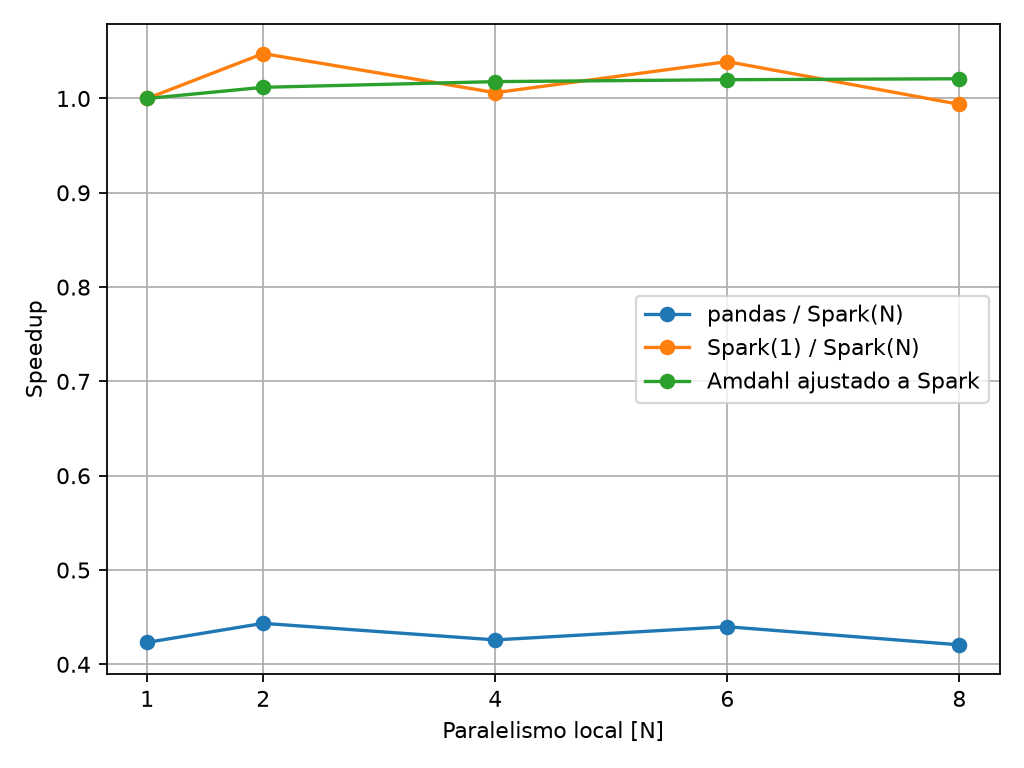

In [3]:
from IPython.display import Image

Image(filename=str(EVIDENCIA_17.parent / "analysis-definitivo-233b34ac-a09f-40c9-be71-5570f25affbd" / "speedup.png"))
